# _Unsupervised Learning:   Hierarchical Clustering and K-Means_


## Agglomerative Hierarchical Clustering

Useful readings can be found [here](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.AgglomerativeClustering.html) and [here](https://en.wikipedia.org/wiki/Hierarchical_clustering).


### Short Demo

In [1]:
from sklearn.cluster import AgglomerativeClustering
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Values extracted from the official scikit-learn documentation (check the first link).
X = np.array([[1, 2], [1, 4], [1, 0],
              [4, 2], [4, 4], [4, 0]])

In [3]:
X

array([[1, 2],
       [1, 4],
       [1, 0],
       [4, 2],
       [4, 4],
       [4, 0]])

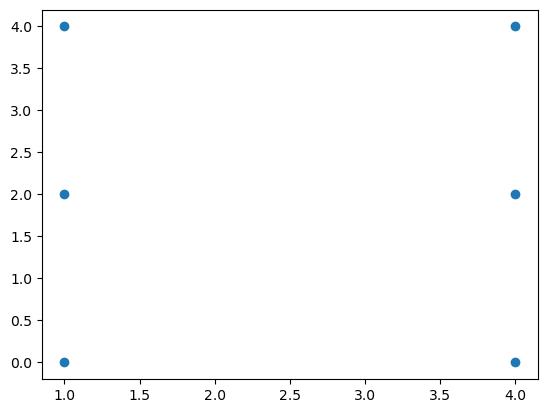

In [4]:
# Visualise data
plt.scatter(X[:,0], X[:,1])

In [5]:
# Agglomerative Hierarchical Clustering model with no parameters
aggl_model_demo = AgglomerativeClustering().fit(X)

In [6]:
aggl_model_demo

AgglomerativeClustering()

In [7]:
# Cluster labels for each point
aggl_model_demo.labels_

array([1, 1, 1, 0, 0, 0])

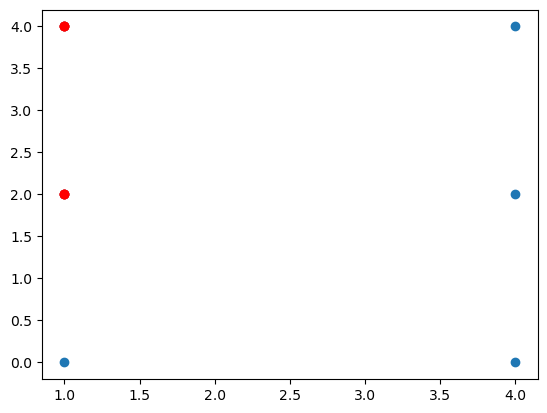

In [8]:
# Visualise data

plt.scatter(X[:,0], X[:,1])
plt.scatter(X[aggl_model_demo.labels_,0], X[aggl_model_demo.labels_,1], c='r')

### Task 0

Play around with `data.txt` and:
* Plot data before applying the _Agglomerative Hierarchical Clustering_ algorithm (**TO DO1**);
* **TO DO2**:
    - Define a new variable _X_ to store `data_txt`,
    - Apply the _Agglomerative Hierarchical Clustering_ algorithm and modify its parameters for 15 clusters;
    - Write down your observations for different values of `affinity` (_"euclidean"_ or _"manhattan"_) and `linkage` (_"ward"_ or _"complete"_);
* Visualise the obtained clusters.

_Note:_ At the end of this task, please use the `markdown` option provided in the notebook for your observations.

In [9]:
# Load data for this exercise
data_txt = np.loadtxt('data.txt', usecols=(0, 1), skiprows=1)

In [10]:
data_txt

array([[665845., 557965.],
       [597173., 575538.],
       [618600., 551446.],
       ...,
       [650661., 861267.],
       [599647., 858702.],
       [684091., 842566.]])

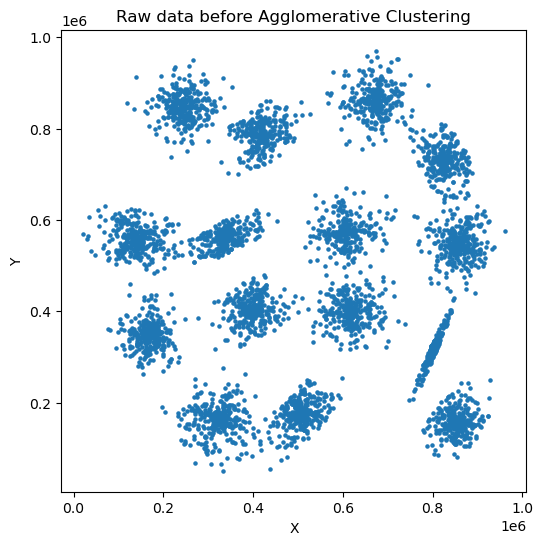

In [11]:
# TO DO1

plt.figure(figsize=(6,6))
plt.scatter(data_txt[:,0], data_txt[:,1], s=5)
plt.title("Raw data before Agglomerative Clustering")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

In [12]:
# TO DO2
X = data_txt

# Define model
from sklearn.cluster import AgglomerativeClustering

aggl = AgglomerativeClustering(
    n_clusters=15,
    metric='euclidean',  
    linkage='ward'          
)

# Use the fit_predict() function
y_predict = aggl.fit_predict(X)

# Get the labels and use them in your plot
labels = aggl.labels_

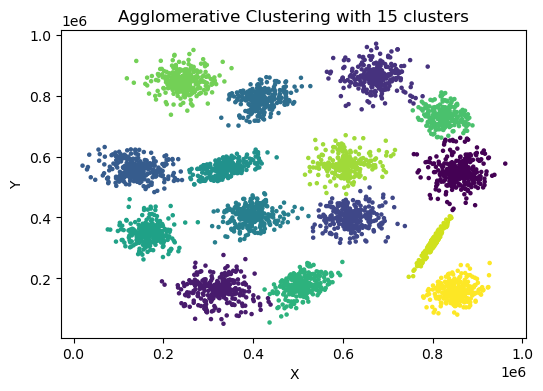

In [13]:
# Expected plot for TO DO2

plt.figure(figsize=(6,4))
plt.scatter(X[:, 0], X[:, 1], c=labels, s=5) 
plt.title("Agglomerative Clustering with 15 clusters")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

**TO DO3**: Use the _Nearest Centroid_ [documentation](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.NearestCentroid.html) to compute the centroids of each cluster.

In [14]:
# TO DO3
from sklearn.neighbors import NearestCentroid

centroid_model = NearestCentroid()
centroid_model.fit(X, labels)
centroids = centroid_model.centroids_

# Expected Output:
print('Centroids:')
print(centroids)

Centroids:
[[858523.47107438 549109.0137741 ]
 [321607.60349854 161194.23323615]
 [672400.67597765 861555.2849162 ]
 [619663.6884273  398658.75074184]
 [140019.83526012 558305.60115607]
 [417799.69426752 787001.99363057]
 [399223.625      404923.23579545]
 [337858.94189602 562276.80428135]
 [167727.3880597  348147.6       ]
 [508441.62931034 176054.77873563]
 [823717.6744186  733102.37209302]
 [244654.8856305  847642.04105572]
 [606060.5959596  574146.15824916]
 [802138.44551282 319314.90384615]
 [852675.82769231 157386.94461538]]


**TO DO4:** Iterate through the obtained labels and visualise each cluster with its corresponding centroid.

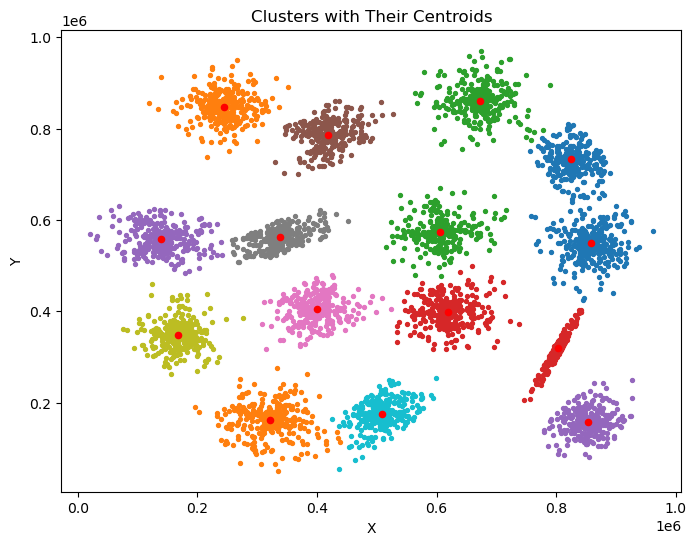

In [15]:
unique_labels = np.unique(labels)

# TO DO4
plt.figure(figsize=(8, 6))

for label in unique_labels:
    cluster_points = X[labels == label]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], s=8)
    centroid_x, centroid_y = centroids[label]
    plt.scatter(centroid_x, centroid_y, c='red', s=80, marker='.')

plt.title("Clusters with Their Centroids")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

In [16]:
# Expected Output:

### Final Observations (Agglomerative Clustering)

- The raw `data.txt` file clearly contains many well-separated groups, so hierarchical clustering works very well.
- With **15 clusters**, the Agglomerative Clustering algorithm correctly recovers all natural blobs in the dataset.
- The best results appear with **metric = "euclidean"** and **linkage = "ward"**, which produce compact and clearly separated clusters.
- Using **"manhattan"** distance or **"complete"** linkage changes cluster shape (more stretched or irregular), but the overall grouping remains similar.
- The computed centroids are located correctly in the middle of each cluster, confirming that the clustering was stable and meaningful.

## K-Means

Please refer to this [document](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html) for more information.

### Task 1

Play around with `data.txt` and:
* **TO DO1**: Apply the _K-Means Clustering_ algorithm and generate 15 clusters;
* **TO DO2**: Write down your observations for the `algorithm` parameter (_"lloyd"_ or _"elkan"_);
* **TO DO3**: Compute the centroids for each cluster;
* **TO DO4**: Visualise the obtained clusters with their corresponding centroids.

_Note:_ At the end of this task, please use the `markdown` option provided in the notebook for your observations.

In [17]:
# TO DO1

from sklearn.cluster import KMeans

X = data_txt 

kmeans = KMeans(
    n_clusters=15,
    random_state=0,
    n_init=10,
    algorithm='lloyd' 
)

kmeans_labels = kmeans.fit_predict(X)

Lloyd  inertia: 8913733944168.668  time: 0.0392911434173584
Elkan  inertia: 8913733944168.668  time: 0.04370546340942383


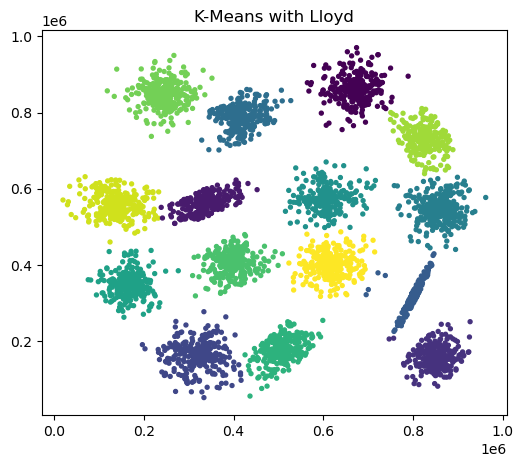

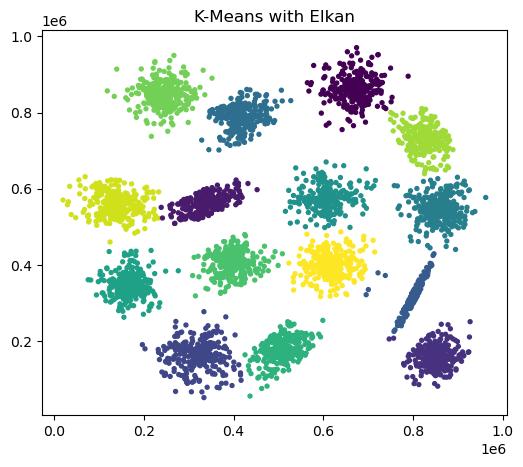

In [18]:
from sklearn.cluster import KMeans
import time

X = data_txt

# Lloyd
start = time.time()
kmeans_lloyd = KMeans(
    n_clusters=15,
    random_state=0,
    n_init=10,
    algorithm='lloyd'
).fit(X)
time_lloyd = time.time() - start

# Elkan
start = time.time()
kmeans_elkan = KMeans(
    n_clusters=15,
    random_state=0,
    n_init=10,
    algorithm='elkan'
).fit(X)
time_elkan = time.time() - start

print("Lloyd  inertia:", kmeans_lloyd.inertia_, " time:", time_lloyd)
print("Elkan  inertia:", kmeans_elkan.inertia_, " time:", time_elkan)

import matplotlib.pyplot as plt

labels_lloyd = kmeans_lloyd.labels_
labels_elkan = kmeans_elkan.labels_

# Lloyd
plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], c=labels_lloyd, s=8)
plt.title("K-Means with Lloyd")
plt.show()

# Elkan
plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], c=labels_elkan, s=8)
plt.title("K-Means with Elkan")
plt.show()

In [19]:
# TO DO2

### Observations for the K-Means `algorithm` parameter

- The `lloyd` algorithm is the classic K-Means implementation. It recomputes all distances at every iteration.
- The `elkan` algorithm includes mathematical optimizations (triangle inequality) that allow it to skip some distance calculations.
- On this 2D dataset (`data.txt`), **both algorithms produce almost identical clusters and centroids**, because the cluster geometry is simple.
- The main difference is speed: `elkan` tends to run faster than `lloyd`, especially when clusters are well separated.
- Therefore, visually the results look the same, but internally `elkan` is more efficient.

In [20]:
# TO DO3

centroids_kmeans = kmeans.cluster_centers_

print("Centroids:")
print(centroids_kmeans)

Centroids:
[[670929.06818182 862765.73295454]
 [337264.76291793 562123.37993921]
 [852058.45259939 157685.52293578]
 [320602.55       161521.85      ]
 [801616.78164557 321123.34177215]
 [417799.69426752 787001.99363057]
 [858947.97134671 546259.65902579]
 [606380.41554054 574534.59121622]
 [167856.14071856 347812.71556886]
 [507818.31339031 175610.41595441]
 [398870.04843305 404924.06552707]
 [244654.8856305  847642.04105572]
 [823421.2507837  731145.27272727]
 [139395.22898551 558143.94202899]
 [617926.67761194 399415.94925373]]


In [21]:
# Expected Output:
centroids

array([[858523.47107438, 549109.0137741 ],
       [321607.60349854, 161194.23323615],
       [672400.67597765, 861555.2849162 ],
       [619663.6884273 , 398658.75074184],
       [140019.83526012, 558305.60115607],
       [417799.69426752, 787001.99363057],
       [399223.625     , 404923.23579545],
       [337858.94189602, 562276.80428135],
       [167727.3880597 , 348147.6       ],
       [508441.62931034, 176054.77873563],
       [823717.6744186 , 733102.37209302],
       [244654.8856305 , 847642.04105572],
       [606060.5959596 , 574146.15824916],
       [802138.44551282, 319314.90384615],
       [852675.82769231, 157386.94461538]])

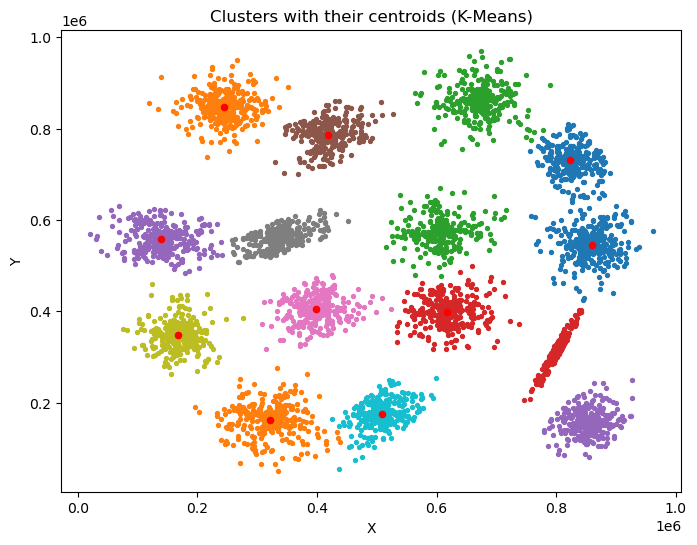

In [22]:
unique_labels = np.unique(labels)

# TO DO4

plt.figure(figsize=(8, 6))

for label in unique_labels:
    cluster_points = X[labels == label]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], s=8)
    cx, cy = centroids_kmeans[label]
    plt.scatter(cx, cy, c='red', s=80, marker='.')

plt.title("Clusters with their centroids (K-Means)")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

### Final Observations (K-Means)

- K-Means successfully identified the 15 natural clusters in `data.txt`, producing compact and clearly separated groups.
- The computed centroids are located in the center of each cluster, confirming that the algorithm converged correctly.
- The `lloyd` and `elkan` algorithms generated almost identical clusters and centroids; the main difference is that `elkan` ran faster due to its optimized distance computations.
- Overall, K-Means performs very well on this dataset because the clusters are spherical, well-separated, and balanced.


### Task 2

Try to modify the number of clusters for `data2.txt` and write down your observations for the _Agglomerative Hierarchical Clustering_ model.

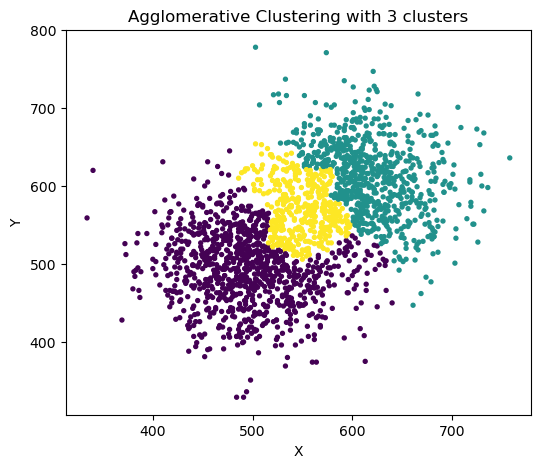

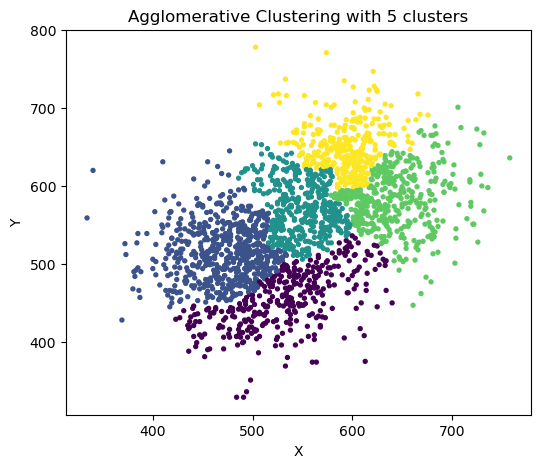

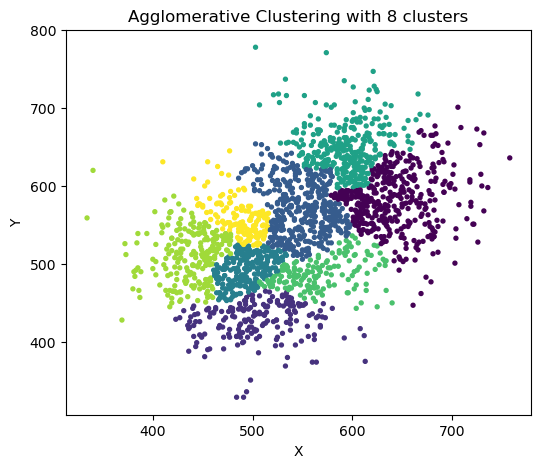

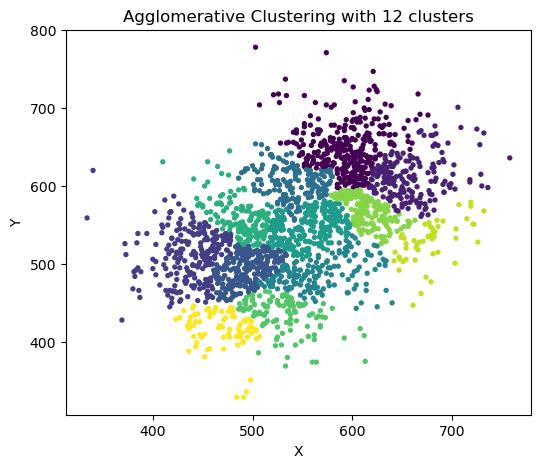

In [23]:
data2 = np.loadtxt('data2.txt', usecols=(0, 1), skiprows=1)
X2 = data2

from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt

cluster_numbers = [3, 5, 8, 12]

for k in cluster_numbers:
    model = AgglomerativeClustering(
        n_clusters=k,
        metric='euclidean',
        linkage='ward'
    )
    
    labels_k = model.fit_predict(X2)
    
    plt.figure(figsize=(6, 5))
    plt.scatter(X2[:, 0], X2[:, 1], c=labels_k, s=8)
    plt.title(f"Agglomerative Clustering with {k} clusters")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.show()

### Observations – Agglomerative Hierarchical Clustering on `data2.txt`

1. **Effect of changing the number of clusters:**
   - With **3 clusters**, the algorithm merges several dense regions together. The result looks coarse, because multiple natural subgroups are forced into large combined clusters.
   - With **5 clusters**, the separation becomes clearer: the upper, lower, and central regions start to split into more meaningful groups.
   - With **8 clusters**, the structure of the dataset becomes much more visible. Many of the natural "blobs" appear as individual clusters.
   - With **12 clusters**, the dataset becomes over-segmented. Some natural groups are split into multiple smaller clusters even though they visually belong together.

2. **Agglomerative behavior:**
   - Agglomerative Clustering starts with every point as its own cluster and successively merges the closest ones.
   - Because merging cannot be undone, the choice of `n_clusters` strongly affects the final result.

3. **General conclusion:**
   - A small number of clusters merges distinct groups into larger ones.
   - A large number of clusters breaks natural shapes into unnecessary smaller pieces.
   - The best cluster number is the one that visually matches the natural structure of the data (around **5–8** for `data2.txt`).